# QICK-DAWG Demo Notebook with Fine Resolution Timing (200 ps)

This notebook is an extension of the counting demo for QICK-DAWG, covering fine timing sequences.

Our instrumentation setup, used for this notebook, is an RFSoC4x2 modified as shown in the demo. Additional setup includes:

- Our microwave output is connected to QICK channel 0, to a microwave amplifier, to a wirebond. 
- Our readout is a Avalanche Photodiode Module, which is connected to the input to QICK.
- Our laser is gated by PMOD channel 0 which is connected to a an AOM driver.

In [1]:
# (requires) setup.py, run to show version of qickdawg installed
!pip show qickdawg

Name: qickdawg
Version: 1.2.1
Summary: Software for full quantum control of nitrogen-vacancy defects and other quantum defects in diamond
Home-page: 
Author: 
Author-email: Andy Mounce <amounce@sandia.gov>, Emmeline Riendeau <eriendeau@uchicago.edu>
License: MIT License 

Copyright 2023 National Technology & Engineering Solutions of Sandia, LLC (NTESS). Under the terms of Contract DE-NA0003525 with NTESS, the U.S. Government retains certain rights in this software.

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substa

In [2]:
%load_ext autoreload
%autoreload 2
# %matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from copy import copy
import qickdawg as qd

from scipy.optimize import curve_fit
from scipy.signal import find_peaks

from importlib.metadata import version
version('numpy')

from qickdawg.finetimingsuite.visualization import Visualizer

c:\Users\QT3 User Facility\Documents\qick-dawg\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# TODO: Update the IP address to match your setup
qd.start_client('192.168.3.1')

In [126]:
default_config = qd.NVConfiguration()
# TODO: Set all of these parameters based on your setup and experiment goals.

# Hardware channels
default_config.mw_channel = 0
default_config.adc_channel = 0
default_config.laser_gate_pmod = 0       # PMOD0_0

# Photon Counting Params
default_config.edge_counting = True
default_config.high_threshold = 8000
default_config.low_threshold = 500

# MW pulse parameters # TODO: Adjust these for your set-up / NV
default_config.mw_pi_ftns = 65.8
default_config.mw_pi2_ftns = default_config.mw_pi_ftns / 2     
default_config.mw_nqz = 1
default_config.mw_fMHz = 1838 + 8.33
default_config.mw_gain = 32767            # NOTE: Adjust based on your Amplifier

# Timing delays
default_config.mw_to_laser_delay_tns = 555 # Laser turn-on lag relative to MW
default_config.relax_delay_tus = 2        # Spin relaxation delay

# Readout timing
default_config.laser_on_tus = 6
default_config.readout_reference_start_tus = 5
# NOTE: The following are determined from the CD experiment
default_config.readout_integration_tns = 633
default_config.laser_readout_offset_tus = 1.159 

# Experiment control
default_config.reps = 10000
default_config.pre_init = True
default_config.get_reference = True       # If True, collect MW-off reference readouts

<a id="laser"></a>
### Laser On / Off

In [127]:
qd.laser_on(copy(default_config))

0

In [128]:
qd.laser_off(copy(default_config))

0

### Check ADC Channel Counts 
rerun until you identify a sharp spike corresponding to a photon count

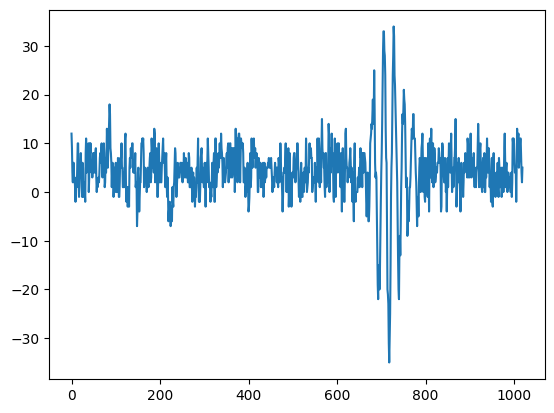

In [71]:
data = qd.check_readout(copy(default_config))
plt.plot(data)

<a id="top"></a>
# Experiments
1. [PODMR](#podmr)
2. [RABI](#rabi)
3. [Ramsey](#ramsey)
4. [Hahn Echo](#hahn-echo)
5. [CPMG](#cpmg)
6. [T1](#t1)

<a id="podmr"></a>
### PODMR
[Laser](#laser)

Maximum Amplifier Gain: 32767

### Recommended Settings:
- coarse sweep: gain=32767, duration=60ns
- fine sweep: gain=2000, duration=650

In [114]:
from qickdawg.finetimingsuite.podmr_fine_res import PODMRFineRes

config = copy(default_config)

# NOTE: If using a microwave frequency over 2.5 GHz, change default nqz from 1 to 2
# default_config.mw_nqz = 2

# frequency sweep parameters
start_MHz = 1840
stop_MHz = 1850
step_MHz = 0.2

config.add_linear_sweep('mw', 'fMHz', start=start_MHz, stop=stop_MHz, delta=step_MHz)

# microwave amplifier gain
config.mw_gain = 2000

#pulse duration (ns)
config.mw_pi_ftns = 650

# number of repetitions
config.reps = 150000

prog = PODMRFineRes(config)
podmr_data = prog.acquire(progress=True)


Requested 1840 to 1850 by 0.2
Instead using 1839.9999996185302 to 1850.0000186920165 by 0.20000038146972654 in 51 steps


100%|██████████| 7650000/7650000 [02:20<00:00, 54321.78it/s]


In [74]:
from qickdawg.finetimingsuite.podmr_fine_res import PODMRFineRes

config = copy(default_config)

# NOTE: If using a microwave frequency over 2.5 GHz, change default nqz from 1 to 2
# default_config.mw_nqz = 2

# frequency sweep parameters
start_MHz = 1840
stop_MHz = 1870
step_MHz = 0.5

config.add_linear_sweep('mw', 'fMHz', start=start_MHz, stop=stop_MHz, delta=step_MHz)

# microwave amplifier gain
config.mw_gain = 32767

#pulse duration (ns)
config.mw_pi_ftns = 70

# number of repetitions
config.reps = 150000

prog = PODMRFineRes(config)
podmr_data = prog.acquire(progress=True)


Requested 1840 to 1870 by 0.5
Instead using 1839.9999996185302 to 1870.0000225067138 by 0.5000003814697266 in 61 steps


100%|██████████| 9150000/9150000 [02:37<00:00, 57974.42it/s]


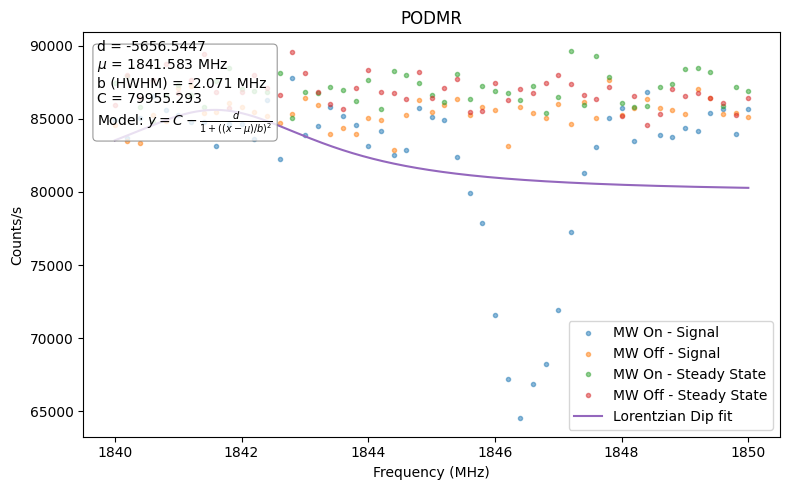

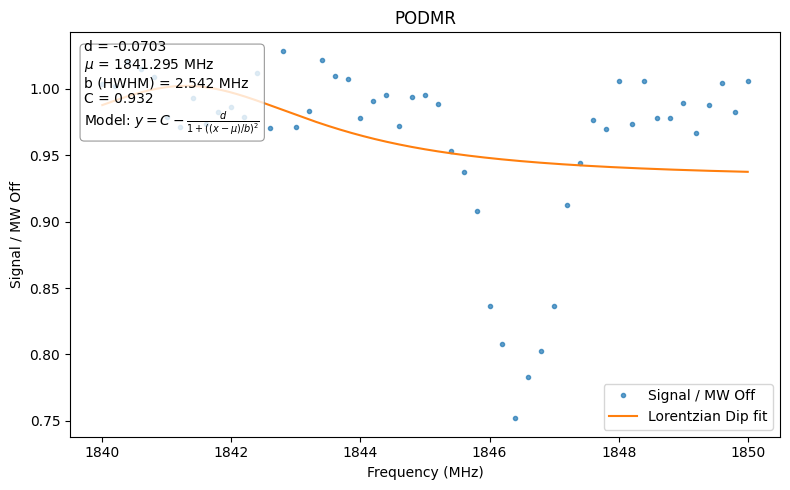

dict_keys(['signal1', 'reference1', 'signal2', 'reference2', 'signal1_cts_s', 'reference1_cts_s', 'signal2_cts_s', 'reference2_cts_s', 'contrast', 'sweep_pts', 'mw_fMHz', 'sweep_param', 'mw_freg', 'mw_fGHz'])

In [116]:
Visualizer.plot_podmr(podmr_data)
Visualizer.plot_podmr(podmr_data, fit=True, view='contrast')
podmr_data.keys() # signal1 (MW on signal), signal2 (MW off signal - ie reference), reference1/2 (MW on/off steady state ref)

<a id="rabi"></a>
### Rabi
[Laser](#laser)

In [117]:
from qickdawg.finetimingsuite.rabi_fine_res import RabiFineRes

config = copy(default_config)

config.add_linear_sweep("mw_duration", "ftns", start=40, stop=800, delta=10)
config.mw_nqz = 1
config.mw_gain = 32767
config.mw_fMHz = 1846.7
config.reps = 150000

prog = RabiFineRes(config)
rabi_data = prog.acquire(progress=True)


Requested 40 to 800 by 10
Instead using 40.07975260416667 to 797.7294921875 by 9.969075520833334 in 77 steps


100%|██████████| 11550000/11550000 [03:27<00:00, 55691.32it/s]


In [100]:
from qickdawg.finetimingsuite.rabi_fine_res import RabiFineRes

config = copy(default_config)

config.add_linear_sweep("mw_duration", "ftns", start=100, stop=12000, delta=400)
config.mw_nqz = 1
config.mw_gain = 2000
config.mw_fMHz = 1847
config.reps = 150000

prog = RabiFineRes(config)
rabi_data = prog.acquire(progress=True)


Requested 100 to 12000 by 400
Instead using 100.09765625 to 11699.625651041668 by 399.98372395833337 in 30 steps


100%|██████████| 4500000/4500000 [02:10<00:00, 34577.77it/s]


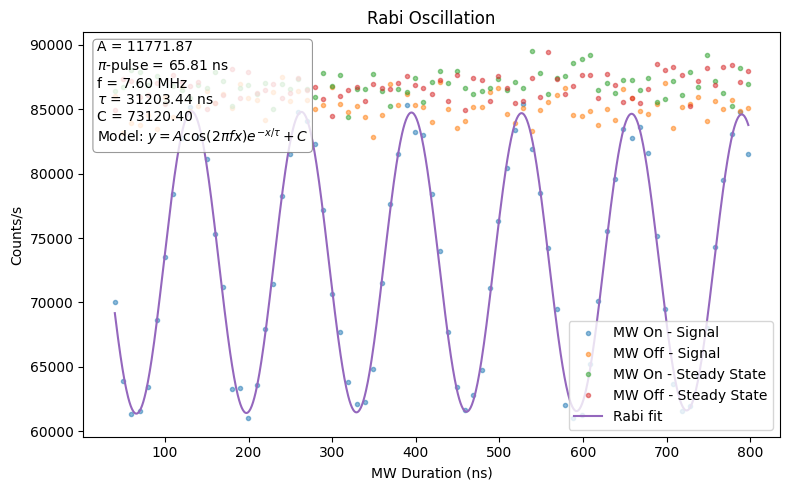

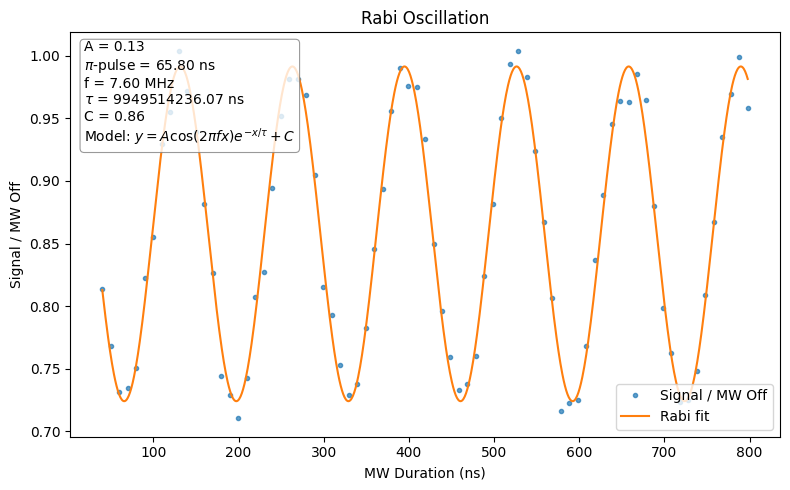

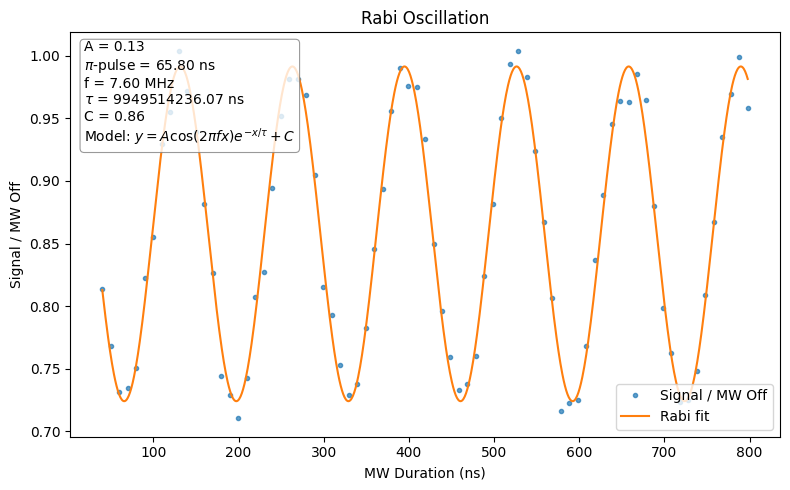

In [118]:
Visualizer.plot_rabi(rabi_data)
Visualizer.plot_rabi(rabi_data, fit=True, view='contrast')

<a id="ramsey"></a>
### Ramsey
[Laser](#laser)

NOTE: Update the configured pi pulse time and frequncy (either here or in the default)

In [131]:
from qickdawg.finetimingsuite.cpmg_xy_fine_res import CPMGXYFineRes

config = copy(default_config)

config.add_linear_sweep('tau', 'ftns', start=100, stop=10000, delta=200)
config.n_cpmg = 0 # NOTE: This is equivalent to a Ramsey experiment
config.reps = 300000

prog = CPMGXYFineRes(config)
ramsey_data = prog.acquire(progress=True)


Requested 100 to 10000 by 200
Instead using 100.09765625 to 9899.698893229168 by 199.99186197916669 in 50 steps


100%|██████████| 15000000/15000000 [06:48<00:00, 36701.57it/s]


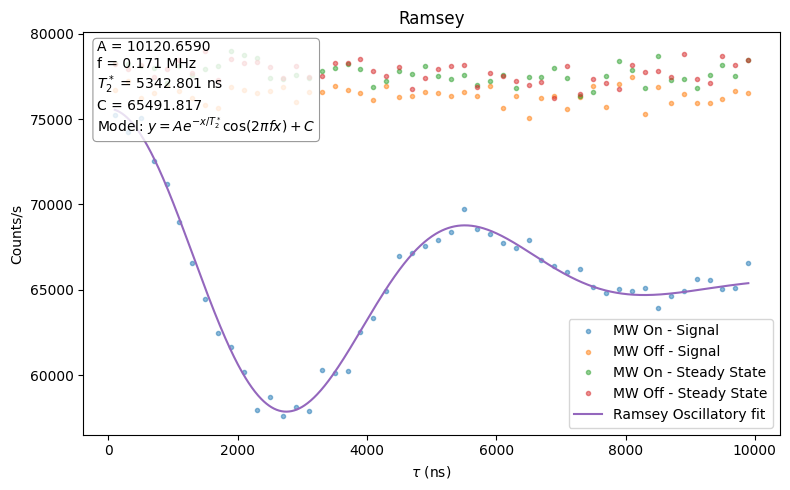

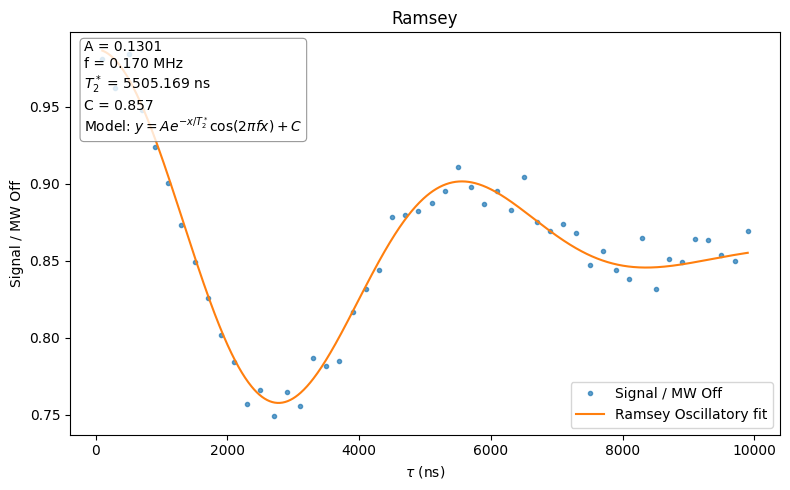

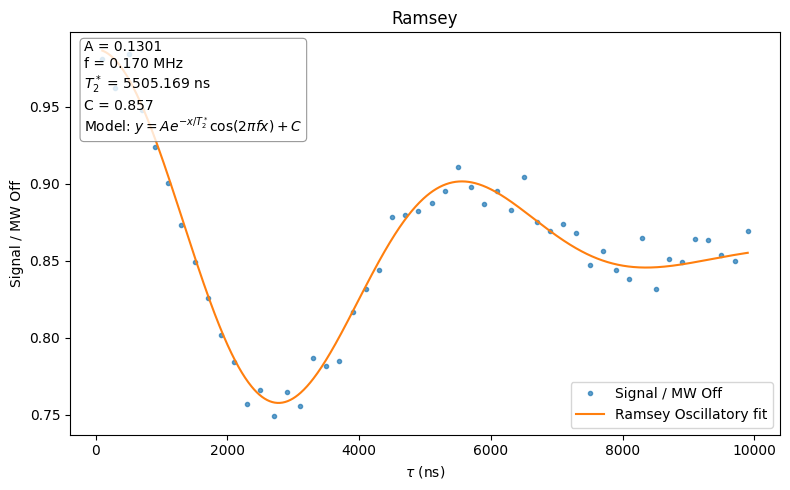

In [132]:
Visualizer.plot_ramsey(ramsey_data)
Visualizer.plot_ramsey(ramsey_data, fit=True, view='contrast')

<a id="hahn-echo"></a>
### Hahn Echo
[Laser](#laser)

In [ ]:
config = copy(default_config)

config.add_exponential_sweep("tau", "ftus", start=0.5, stop=2000, scaling_factor="3/2")
config.n_cpmg = 1 # NOTE: This is equivalent to a Hahn Echo sequence
config.reps = 50000

prog = CPMGXYFineRes(config)
hahnecho_data = prog.acquire(progress=True)

100%|██████████| 1100000/1100000 [25:15<00:00, 725.91it/s]


: 

: 

: 

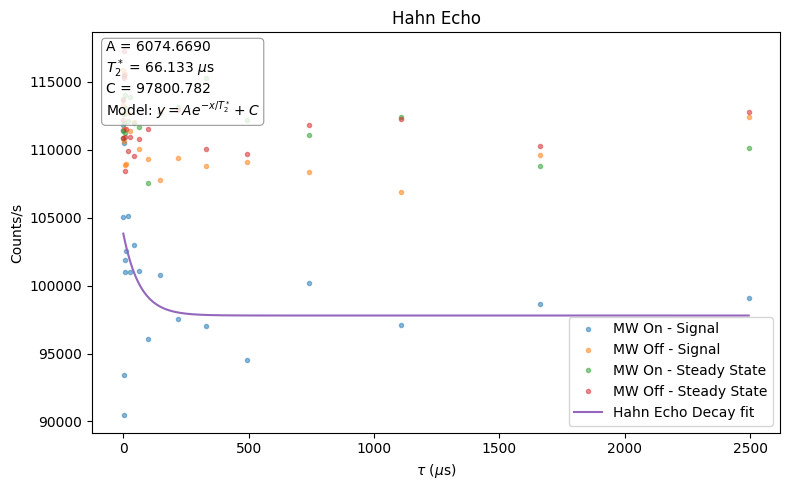

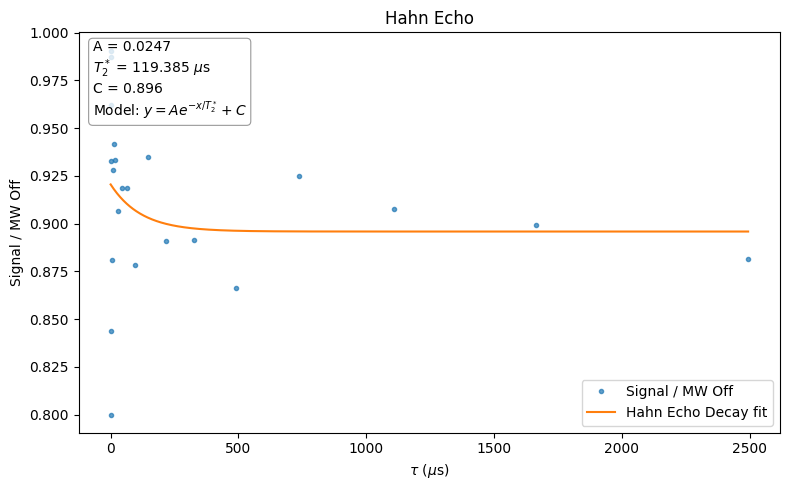

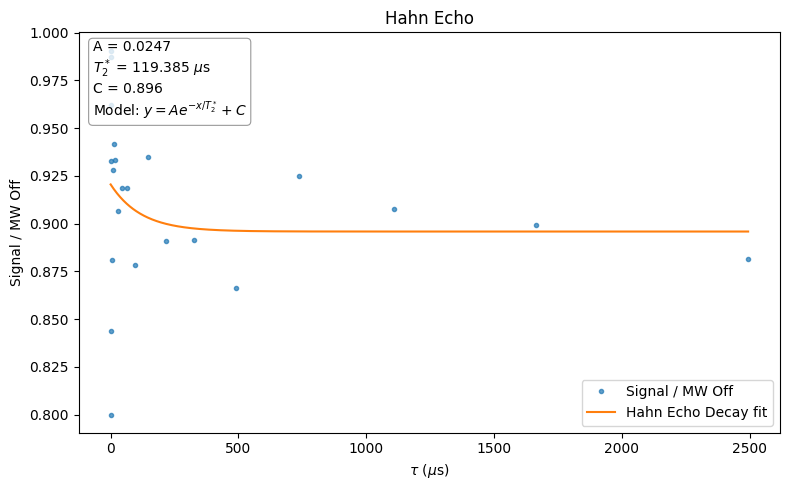

: 

: 

: 

In [ ]:
Visualizer.plot_hahnecho(hahnecho_data)
Visualizer.plot_hahnecho(hahnecho_data, fit=True, view='contrast')

<a id="cpmg"></a>
### CPMG
Carr Purcell Myboom Gill Sequence with N=32

[Laser](#laser)

In [ ]:
config = copy(default_config)

config.add_linear_sweep("tau", "ftns", start=1700, stop=1850, delta=1)

config.n_cpmg = 32
config.reps = 100000
# NOTE: setting config.get_reference = False, will half the experiment duration

prog = CPMGXYFineRes(config)
cpmg_data = prog.acquire(progress=True)


Requested 1700 to 1850 by 1
Instead using 1700.0325520833335 to 1852.6204427083335 by 1.0172526041666667 in 151 steps


100%|██████████| 15100000/15100000 [1:02:21<00:00, 4036.31it/s]


: 

: 

: 

: 

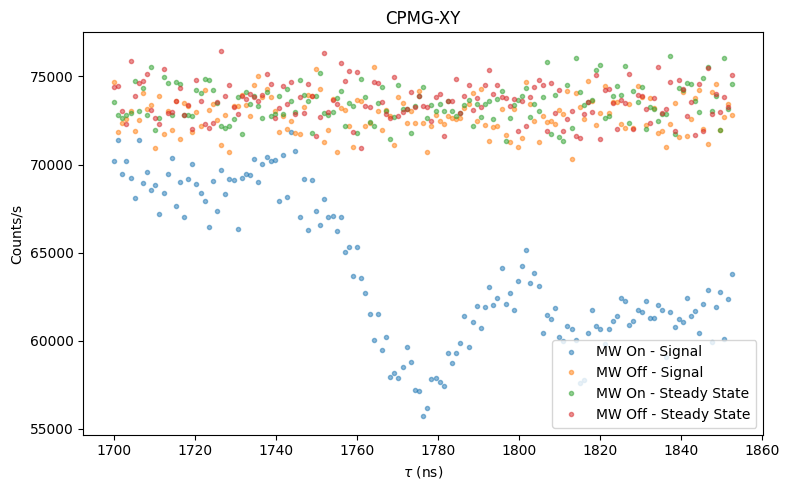

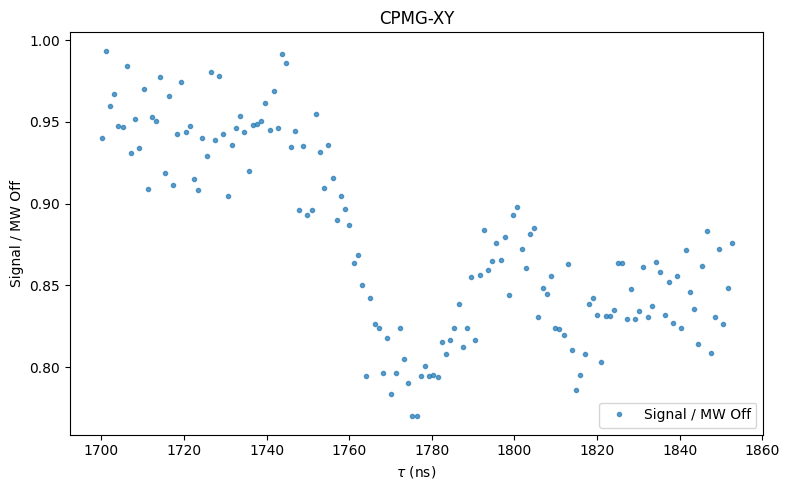

: 

: 

: 

: 

In [ ]:
Visualizer.plot_cpmg(cpmg_data)
Visualizer.plot_cpmg(cpmg_data, view='contrast', contrast_mode='signal_over_off')
# you can still get contrast relative to steady state using with: contrast_mode='signal_over_ss'

<a id="t1"></a>
### T1
[Laser](#laser)

In [ ]:
from qickdawg.finetimingsuite.t1_fine_res import T1FineRes

config = copy(default_config)

config.add_exponential_sweep("delay", "tus", start=10, stop=6000, scaling_factor='3/2')
config.reps = 50000

prog = T1FineRes(config)
t1_data = prog.acquire(progress=True)

100%|██████████| 850000/850000 [33:03<00:00, 428.57it/s]


: 

: 

: 

: 

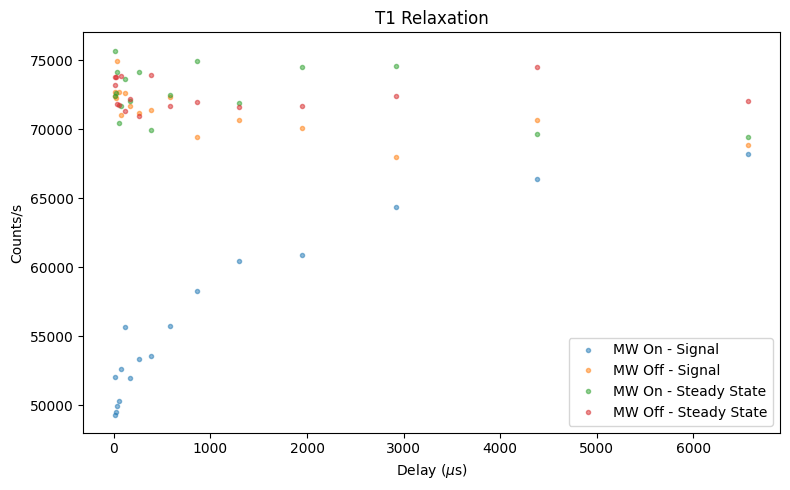

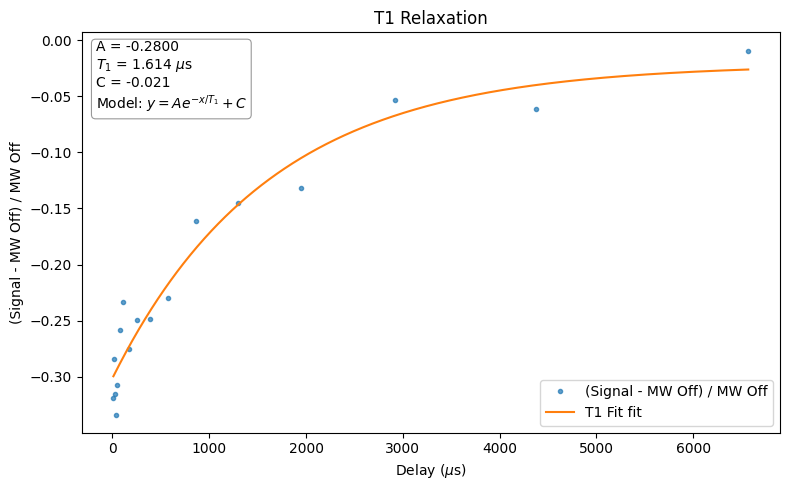

: 

: 

: 

: 

In [ ]:
Visualizer.plot_t1(t1_data, fit=False)
Visualizer.plot_t1(t1_data, fit=True, view='contrast', contrast_mode='signal_minus_off')

: 

: 

: 

: 